In [19]:
import uproot
import numpy as np
import pandas as pd
import os

def smart_round(value, error, sig_figs=2):
    """
    Kerekíti az értéket és a hibát a hiba értékes jegyei alapján.
    """
    if error == 0 or not np.isfinite(error) or value == 0:
        return value, error
    
    order_of_magnitude = np.floor(np.log10(np.abs(error)))
    decimals = int(sig_figs - 1 - order_of_magnitude)
    decimals = max(0, decimals)
    
    rounded_val = np.round(value, decimals)
    rounded_err = np.round(error, decimals)
    
    return rounded_val, rounded_err

# --- BEÁLLÍTÁSOK ---
BASE_DIR = "../output/scintyEfficiency/"
# Az almappák nevei (ezek a mérések/szimulációk sorszámai vagy távolságai)
sub_folders = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12"]
ENERGY_KEV = 662  # Fix energia minden mappához

N_TOTAL = 1.0e6   # Összes indított részecske (beamOn)
MAX_ENERGY = 1500.0
NUM_BINS = 1000
BIN_WIDTH = MAX_ENERGY / NUM_BINS 

data_list = []

print("Feldolgozás indítása...")

for folder_name in sub_folders:
    # Elérési út összerakása: BASE_DIR + almappa + fájlnév
    file_path = os.path.join(BASE_DIR, folder_name, "data.root")
    
    print(f"Fájl feldolgozása: {file_path}...", end="\r")
    
    try:
        with uproot.open(file_path) as file:
            # Hisztogram beolvasása
            # Ha a G4 kódodban más a neve, ellenőrizd! (pl. "Edep" vagy "E_dep")
            hist_values, hist_edges = file["Edep_SD;1"].to_numpy()
            
            # 1. Megkeressük a csúcs környékét
            expected_bin_index = int(ENERGY_KEV / BIN_WIDTH)
            search_range = 5  # Megnöveltük a tartományt a biztonság kedvéért
            
            low_idx = max(0, expected_bin_index - search_range)
            high_idx = min(NUM_BINS - 1, expected_bin_index + search_range + 1)
            
            # 2. Csúcshatásfok számítása: 
            # NEM csak a maximumot vesszük (np.max), hanem a csúcs alatti TERÜLETET (np.sum)
            # A szimulációban a csúcs több bin-re is szétkenődhet.
            peak_counts = np.sum(hist_values[low_idx:high_idx])
            
            # Hatásfok és statisztikai hiba (Poisson)
            raw_eff = peak_counts / N_TOTAL
            raw_err = np.sqrt(peak_counts) / N_TOTAL
            
            # Kerekítés
            final_eff, final_err = smart_round(raw_eff, raw_err, sig_figs=2)
            
            # Távolság kinyerése (Ha a mappanév pl. "10", akkor az 10.0 mm)
            # Ha a mappanevekben van "mm", a replace-szel eltávolítjuk
            try:
                dist_val = float(folder_name.replace("mm", ""))
            except ValueError:
                dist_val = folder_name # Ha nem szám, marad a szöveg
                
            data_list.append({
                "Energia [keV]": ENERGY_KEV,
                "Hatásfok": final_eff,
                "Hatásfok hiba": final_err,
                "Távolság [cm]": dist_val
            })
            
    except (FileNotFoundError, uproot.KeyInFileError, OSError):
        print(f"\n[HIBA] Nem található vagy sérült: {file_path}")
        continue

# Adatok rendezése és mentése
if data_list:
    df = pd.DataFrame(data_list)
    # Rendezzük távolság szerint növekvőbe
    df = df.sort_values("Távolság [cm]")
    
    output_filename = os.path.join(BASE_DIR, "detektor_hatasfok.csv")
    df.to_csv(output_filename, index=False, sep=";")
    
    print(f"\n\nKész! Összesen {len(df)} fájl feldolgozva.")
    print(f"Az eredmény mentve ide: {output_filename}")
    print("\nAz első pár sor:")
    print(df.head())
else:
    print("\nNem sikerült adatokat beolvasni. Ellenőrizd a mappákat!")

Feldolgozás indítása...
Fájl feldolgozása: ../output/scintyEfficiency/12/data.root...

Kész! Összesen 13 fájl feldolgozva.
Az eredmény mentve ide: ../output/scintyEfficiency/detektor_hatasfok.csv

Az első pár sor:
   Energia [keV]  Hatásfok  Hatásfok hiba  Távolság [cm]
0            662   0.10424        0.00032            0.0
1            662   0.05208        0.00023            1.0
2            662   0.03064        0.00018            2.0
3            662   0.02008        0.00014            3.0
4            662   0.01411        0.00012            4.0


/tmp/ipykernel_26165/1644777359.py:21: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.errorbar(


Grafikon elmentve: ../output/scintyEfficiency/hatasfok_grafikon.pdf


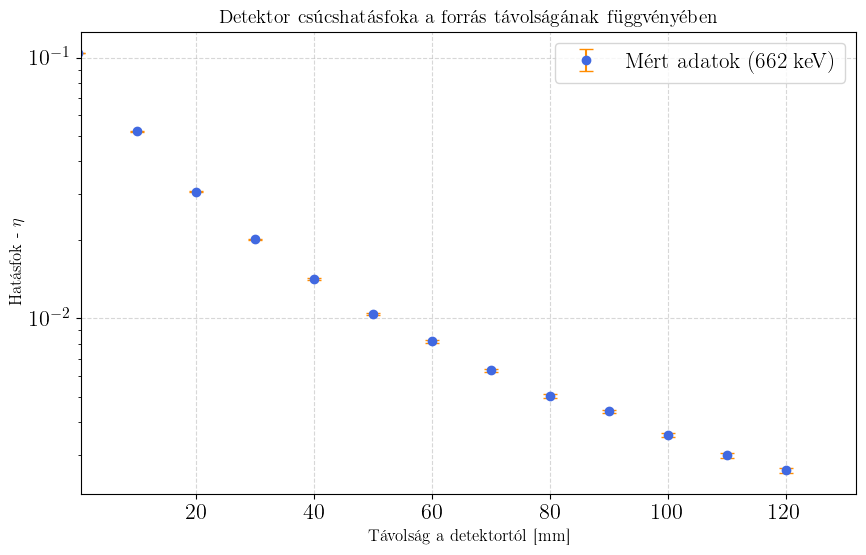

In [20]:

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("stylesheet.mplstyle")

# 1. Adatok beolvasása
csv_path = "../output/scintyEfficiency/detektor_hatasfok.csv"
try:
    df = pd.read_csv(csv_path, sep=";")
except FileNotFoundError:
    print(f"Hiba: A {csv_path} fájl nem található!")
    exit()

# Gondoskodjunk róla, hogy a távolság szerint sorba legyen rendezve a vonalvezetés miatt
df = df.sort_values("Távolság [cm]")

# 2. Grafikon létrehozása
plt.figure(figsize=(10, 6))

# Hibasávos ábrázolás (Errorbar)
plt.errorbar(
    df["Távolság [cm]"] * 10, 
    df["Hatásfok"], 
    yerr=df["Hatásfok hiba"], 
    fmt='o',           # 'o' = pontok, '-' = összekötő vonal
    capsize=5,          # A hiba-tüskék végei
    markersize=6, 
    color='royalblue', 
    ecolor='darkorange', # A hiba sáv színe legyen más, hogy látszódjon
    label=f"Mért adatok ({df['Energia [keV]'].iloc[0]} keV)"
)

# 3. Formázás
plt.title("Detektor csúcshatásfoka a forrás távolságának függvényében", fontsize=14)
plt.xlabel("Távolság a detektortól [mm]", fontsize=12)
plt.ylabel(r"Hatásfok - $\eta$", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0.5, df["Távolság [cm]"].max() * 10 * 1.1)
plt.legend()

# Opcionális: Logaritmikus skála (gyakran hasznos hatásfoknál)
plt.yscale('log')

# 4. Mentés és megjelenítés
output_plot = "../output/scintyEfficiency/hatasfok_grafikon.pdf"
plt.savefig(output_plot, dpi=300)
print(f"Grafikon elmentve: {output_plot}")
plt.show()